In [1]:
# Data wrangling libraries
import pandas as pd
import numpy as np
import time
import warnings
warnings.filterwarnings("ignore") 

# Visualisation libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing libraries
from sklearn import preprocessing
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, RepeatedKFold, cross_val_predict, GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.decomposition import PCA

# Regression libraries
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from lightgbm import LGBMRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)


# Metric libraries
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score



pd.set_option('display.max_columns', None) # display all columns
pd.set_option('display.expand_frame_repr', False) # print all columns and in the same line
pd.set_option('display.max_colwidth', None) # display the full content of each cell
pd.set_option('display.float_format', lambda x: '%.3f' %x) # floats to be displayed with 3 decimal places

c:\Users\bljor\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Set the datasets for analysis and the target variable
df = pd.read_csv("data/data_cleaned.csv")

df_hs = df[df['type_encoded'] == 1]  # Houses
df_apt = df[df['type_encoded'] == 0]  # Apartments

target = 'price'

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38979 entries, 0 to 38978
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   bedroomcount               38979 non-null  float64
 1   habitablesurface           38979 non-null  float64
 2   haslift                    38979 non-null  int64  
 3   hasgarden                  38979 non-null  int64  
 4   hasswimmingpool            38979 non-null  int64  
 5   hasterrace                 38979 non-null  int64  
 6   price                      38979 non-null  float64
 7   hasparking                 38979 non-null  int64  
 8   epcscore_encoded           38979 non-null  float64
 9   buildingcondition_encoded  38979 non-null  float64
 10  region_Brussels            38979 non-null  float64
 11  region_Flanders            38979 non-null  float64
 12  region_Wallonia            38979 non-null  float64
 13  type_encoded               38979 non-null  int

In [4]:
def splitDF(n, df, target):
    """
    Function to split the dataframe based on the requirements on the regression model we need to run
    """
    
    # First split: isolate the target variable
    y = df[target]
    X = df.drop([target], axis=1)
    
    # Second split: train and test as needed to run cross_val_predict
    X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

    # Further split training: training and validation sets for early stopping
    X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=123)
   
    if n == 1:
        return X, y
    
    elif n == 2:
        return X_train_full, y_train_full, X_test, y_test

    elif n == 3:
        return X_test, X_train, X_val, y_test, y_train, y_val
    
    else:
        raise ValueError(f"Invalid mode n={n}. Must be 1, 2 or 3.")



In [5]:
def regResults(df, obs, name, y_true, y_pred):
    """
    Function to return 
    """
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # Return a dictionary with the metrics
    return {
        "Dataset": df,
        "Features": obs,
        "Model": name,
        "R² Score": r2,
        "MAE": mae,
        "RMSE": rmse
    }


In [6]:
def plotPredictions(df, name, y_true, y_pred):
    plt.figure(figsize=(5, 5))
    plt.scatter(y_true, y_pred, alpha=0.5)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], '--r')
    plt.title(f"{name} - {df} — Predicted vs Actual")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# REGRESSION MODELS

In [7]:
def runModels(df, obs, models, cv, results_df=None):
    """
    Funtion to run the whole set of models with their default parameters.
    It tracks runtime and stores evaluation metrics for each model.
    The function:
    - split the dataframe
    - loop through all the models
    - applies scaling to linear models
    - returns a dataframe with the results for each model

    Parameters:
    - df: DataFrame
    - obs: string quoting which features we are using
    - models: dict of model names
    - cv: cross-validation object

    Returns:
    - results_df: DataFrame with performance metrics and runtime for each model
    """

    # Isolate the target variable
    X, y = splitDF(1, df, target)

    # Initiate a list to save the results
    results = []

    # Loop through the models
    for model_name, model in models.items():

        start = time.time()

        # Apply scaling to linear models
        if model_name in ["Linear", "Ridge", "Lasso", "ElasticNet"]:
            pipeline = make_pipeline(StandardScaler(), model)
        else:
            pipeline = make_pipeline(model)

        # Predict using cross-validation
        y_cv_pred = cross_val_predict(pipeline, X, y, cv=cv)

        # Train on full data
        pipeline.fit(X, y)
        y_train_pred = pipeline.predict(X)

        end = time.time()
        runtime_min = round((end - start) / 60, 2)


        # Get Results
        result_cv = regResults("All properties", obs, model_name, y, y_cv_pred)
        result_train = regResults("All properties", obs, model_name, y, y_train_pred)

        # Build dictionary with suffixed metric keys to avoid duplicates
        exclude_keys = ["Model", "Dataset", "Observations", "Features"]
        combined_result = {
            "Model": model_name,
            "Dataset": "All properties",
            "Features": obs,
            "Runtime (min)": runtime_min,
            # Train metrics with suffix
            **{k + " (Train)": v for k, v in result_train.items() if k not in exclude_keys},
            # CV metrics with suffix
            **{k + " (Test)": v for k, v in result_cv.items() if k not in exclude_keys},
        }

        results.append(combined_result)

    new_results_df = pd.DataFrame(results)

    if results_df is not None:
        results_df = pd.concat([results_df, new_results_df], ignore_index=True)
    else:
        results_df = new_results_df

    return results_df


In [8]:
# Set 10-Fold CV
cv = KFold(n_splits=10, shuffle=True, random_state=123)

# Declare the regression models with default parameters
models = { 
    # with default parameters
    "Linear": LinearRegression(),
    "LightGBM": LGBMRegressor(random_state=123, verbosity=-1),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "ElasticNet": ElasticNet(),
    "Decision Tree": DecisionTreeRegressor(random_state=123),
    "Random Forest": RandomForestRegressor(random_state=123),
    "Gradient Boosting": GradientBoostingRegressor(random_state=123),
    "XGBoost": XGBRegressor(random_state=123),
    "CatBoost": CatBoostRegressor(verbose=0, random_state=123),
    "AdaBoost": AdaBoostRegressor(random_state=123),
    "KNN": KNeighborsRegressor()

    # SVR model omitted as they take very long to process
    # "SVR Linear": SVR(kernel='linear'),
    # "SVR Polynomial": SVR(kernel='poly'),
    # "SVR Radial Basis Func.": SVR(kernel='rbf')
}


In [9]:
# Run the models and save the results
results_df = runModels(df_all, "All features", models, cv)
results_df = results_df.sort_values("R² Score (Test)", ascending=False)

print("\nSummary of Regression Results:")
print(results_df)


Summary of Regression Results:
                Model         Dataset      Features  Runtime (min)  R² Score (Train)  MAE (Train)  RMSE (Train)  R² Score (Test)  MAE (Test)  RMSE (Test)
9            CatBoost  All properties  All features          2.260             0.793    54124.110     75141.489            0.752   58513.997    82171.509
8             XGBoost  All properties  All features          0.100             0.816    51231.138     70866.515            0.742   59572.737    83897.211
1            LightGBM  All properties  All features          0.170             0.764    57986.527     80245.622            0.739   60527.585    84374.139
6       Random Forest  All properties  All features          5.670             0.960    23205.782     33101.315            0.722   61779.345    87044.943
7   Gradient Boosting  All properties  All features          1.120             0.691    67539.339     91780.875            0.682   68355.805    93138.984
2               Ridge  All properties  All f

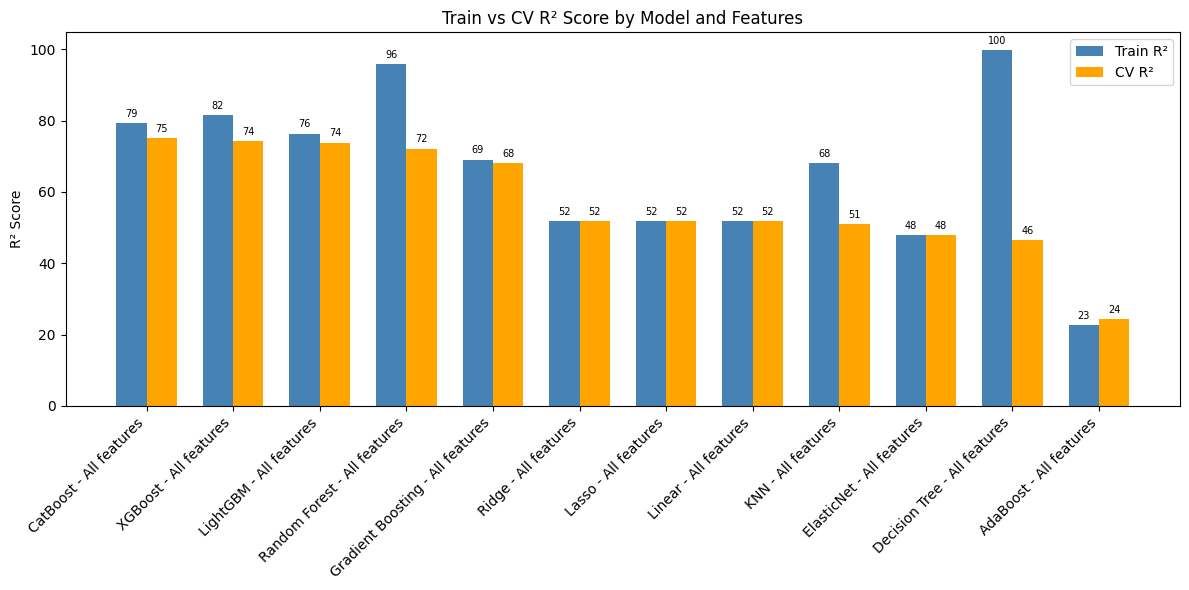

In [10]:
def trainCVresult(results_df):

    results_df["Model + Feat"] = results_df["Model"] + " - " + results_df["Features"]
    labels = results_df["Model + Feat"]
    # multiply by 100 to reduce label size
    r2_train = results_df["R² Score (Train)"]*100  
    r2_cv = results_df["R² Score (Test)"]*100

    x = np.arange(len(labels))  # label locations
    width = 0.35  # width of bars

    fig, ax = plt.subplots(figsize=(12, 6))
    rects1 = ax.bar(x - width/2, r2_train, width, label='Train R²', color='steelblue')
    rects2 = ax.bar(x + width/2, r2_cv, width, label='CV R²', color='orange')

    # Labels & Title
    ax.set_ylabel('R² Score')
    ax.set_title('Train vs CV R² Score by Model and Features')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.legend()

    # Add values on top of bars
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.0f}',
                        xy=(rect.get_x() + rect.get_width()/2, height),
                        xytext=(0, 3),  # offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=7)

    autolabel(rects1)
    autolabel(rects2)

    plt.tight_layout()
    plt.show()

trainCVresult(results_df)

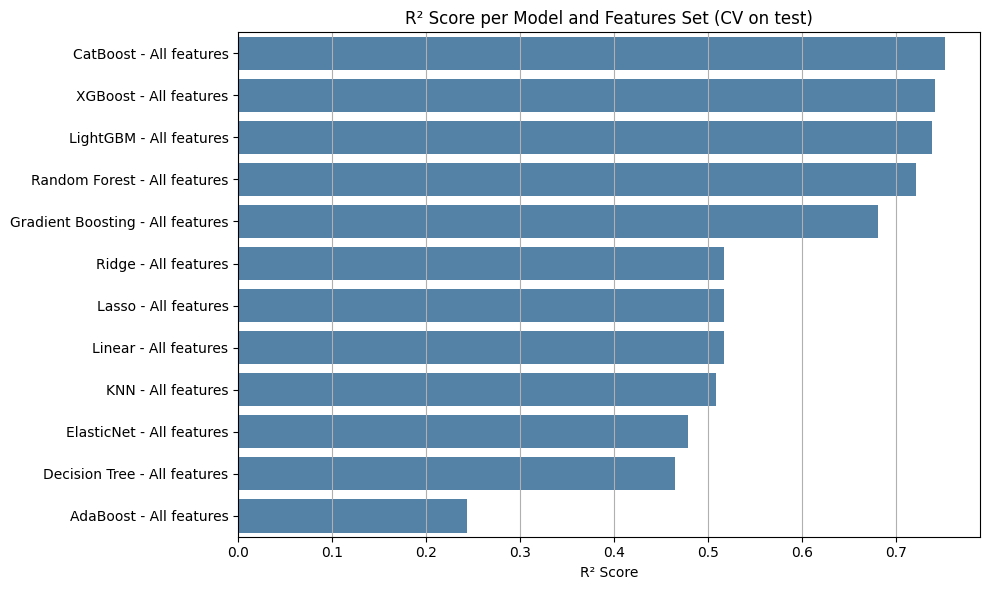

In [11]:
def resultPlot(results_df):
    
    # Create combined label for plotting
    results_df = results_df.copy()  # avoid modifying original
    results_df["Model + Feat"] = results_df["Model"] + " - " + results_df["Features"]

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=results_df,
        y="Model + Feat", x="R² Score (Test)",
        color="steelblue"
    )

    plt.title("R² Score per Model and Features Set (CV on test)")
    plt.xlabel("R² Score")
    plt.ylabel("")
    plt.grid(True, axis='x')
    plt.tight_layout()
    plt.show()


resultPlot(results_df)

In [12]:
# Run the models and save the results
df_all['price'] = np.log1p(df_all['price'])

results_df = runModels(df_all, "All feat. + y log", models, cv, results_df=results_df)
results_df = results_df.sort_values("R² Score (Test)", ascending=False)

print("\nSummary of Regression Results:")
print(results_df)


Summary of Regression Results:
                Model         Dataset           Features  Runtime (min)  R² Score (Train)  MAE (Train)  RMSE (Train)  R² Score (Test)  MAE (Test)  RMSE (Test)                      Model + Feat
21           CatBoost  All properties  All feat. + y log          2.210             0.813        0.161         0.212            0.782       0.173        0.229                               NaN
20            XGBoost  All properties  All feat. + y log          0.120             0.832        0.153         0.201            0.772       0.177        0.234                               NaN
13           LightGBM  All properties  All feat. + y log          0.080             0.788        0.172         0.226            0.767       0.180        0.237                               NaN
18      Random Forest  All properties  All feat. + y log          6.750             0.964        0.068         0.093            0.754       0.182        0.244                               NaN
0  

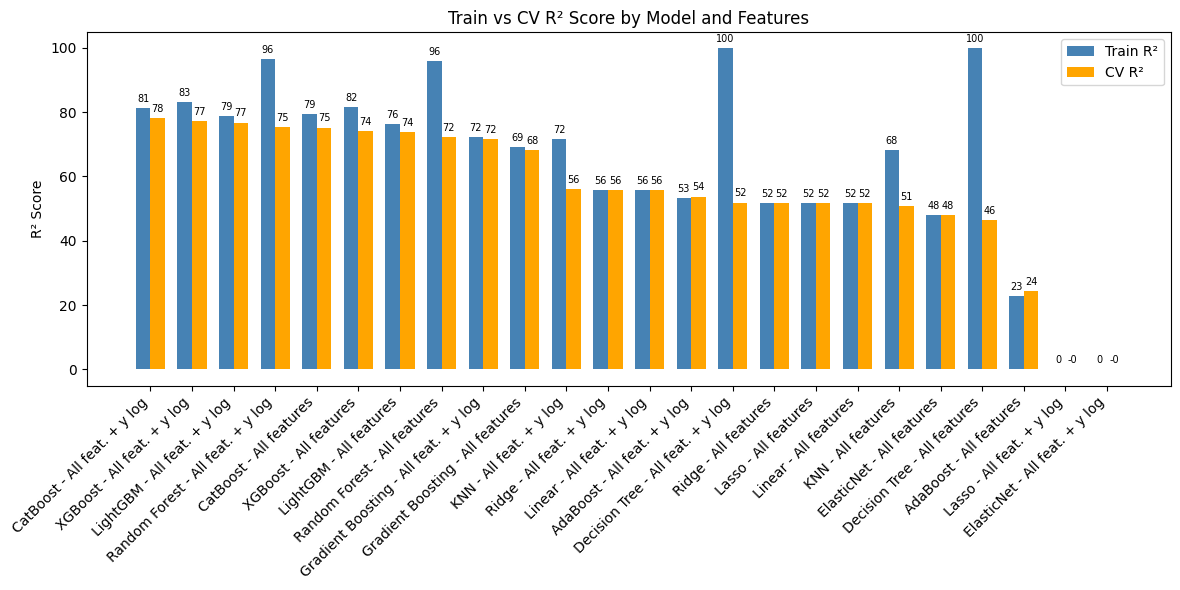

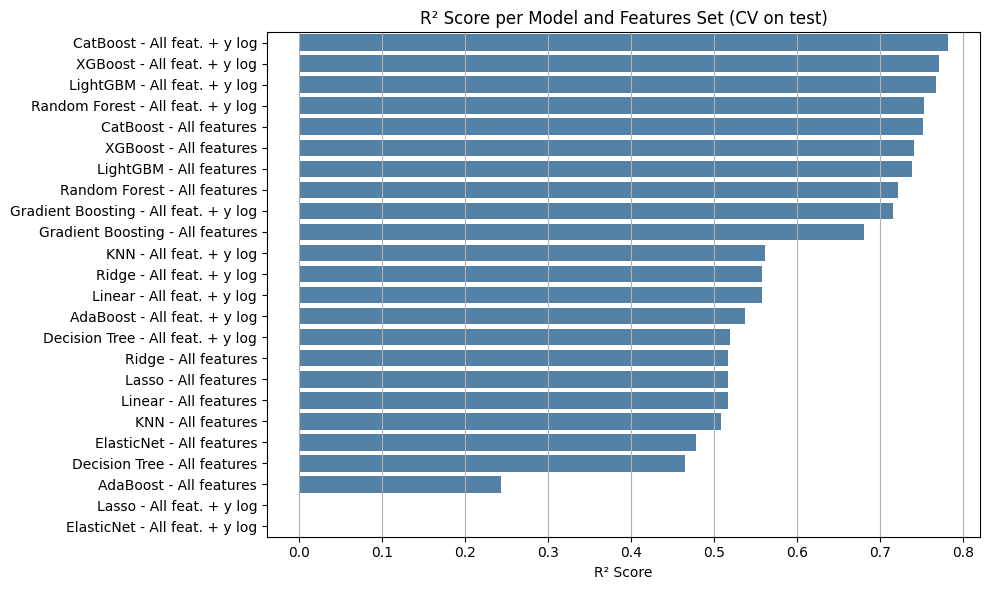

In [13]:
trainCVresult(results_df)
resultPlot(results_df)

In [14]:
results_1stRound = results_df
results_df = results_df.drop('Model + Feat', axis=1).sort_values("RMSE (Test)", ascending=True).head(3)
results_df

,Model,Dataset,Features,Runtime (min),R² Score (Train),MAE (Train),RMSE (Train),R² Score (Test),MAE (Test),RMSE (Test)
21,CatBoost,All properties,All feat. + y log,2.210,0.813,0.161,0.212,0.782,0.173,0.229
20,XGBoost,All properties,All feat. + y log,0.120,0.832,0.153,0.201,0.772,0.177,0.234
13,LightGBM,All properties,All feat. + y log,0.080,0.788,0.172,0.226,0.767,0.180,0.237


Conclusions after the first round:

- Putting price in log scale performs better
- CatBoost, LightGBM and XGBoost models perform the best
- Random Forest also has good results, but overfits the data and very consuming (run time triples the other models) 

We will then try to develop the best model (CATBOOST) using price in log scale

# FINE TUNNING CATBOOST

In [15]:
def CatBoost_withEarlyStop(df, obs, target, results_df=None):

    # Get categorical feature names
    cat_features = df.select_dtypes(include=['object']).columns.tolist()
    
    # Split data into train, val, test
    X_train, X_val, X_test, y_train, y_val, y_test = splitDF(3, df, target)
    
    cat_params = {
        'depth': [4, 6, 8],
        "learning_rate": [0.01, 0.05, 0.1],
        'l2_leaf_reg': [1, 3, 5],
        'bagging_temperature': [0, 0.2, 0.5],
        'iterations': [500, 1000, 1500]
    }
    
    cat_model = CatBoostRegressor(
        eval_metric='RMSE',
        cat_features=cat_features,
        verbose=0,
        random_state=123,
        early_stopping_rounds=50
    )
    
    cat_search = RandomizedSearchCV(
        cat_model,
        cat_params,
        n_iter=50,
        cv=5,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1,
        verbose=1,
        random_state=123
    )
    
    # Fit with validation set for early stopping
    cat_search.fit(
        X_train, y_train,
        eval_set=(X_val, y_val),
        cat_features=cat_features
    )
    
    print("\nBest Hyperparameters for CatBoost:")
    for param, value in cat_search.best_params_.items():
        print(f"\t{param}: {value}")
    
    best_cat = cat_search.best_estimator_
    y_train_pred = best_cat.predict(X_train)
    y_val_pred = best_cat.predict(X_val)
    y_test_pred = best_cat.predict(X_test)
    
   
    # Compute results dicts
    result_train = regResults("All properties", obs, "CatBoost (Train)", y_train, y_train_pred)
    result_val = regResults("All properties", obs, "CatBoost (Val)", y_val, y_val_pred)
    result_test = regResults("All properties", obs, "CatBoost (Test)", y_test, y_test_pred)

    combined_result = {
        "Model": "CatBoost",
        "Dataset": "All properties",
        "Features": obs,
        "Runtime (min)": None
    }

    exclude_keys = ["Model", "Dataset", "Observations", "Features"]
    for suffix, result in zip(["Train", "Val", "Test"], [result_train, result_val, result_test]):
        for k, v in result.items():
            if k not in exclude_keys:
                combined_result[f"{k} ({suffix})"] = v
    
    # Append or create DataFrame
    if results_df is not None:
        results_df = pd.concat([results_df, pd.DataFrame([combined_result])], ignore_index=True)
    else:
        results_df = pd.DataFrame([combined_result])
    
    return results_df


In [16]:
start = time.time()
results_df = CatBoost_withEarlyStop(df_all, "RsearchCV", target, results_df)
end = time.time()

code_run = (end - start) / 60
results_df.at[results_df.index[-1], "Runtime (min)"] = code_run

results_df = results_df.sort_values("RMSE (Test)", ascending=True)  # Usually lower RMSE is better

print("\nSummary of Regression Results:")
print(results_df)


Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best Hyperparameters for CatBoost:
	learning_rate: 0.05
	l2_leaf_reg: 5
	iterations: 1500
	depth: 6
	bagging_temperature: 0

Summary of Regression Results:
      Model         Dataset           Features  Runtime (min)  R² Score (Train)  MAE (Train)  RMSE (Train)  R² Score (Test)  MAE (Test)  RMSE (Test)  R² Score (Val)  MAE (Val)  RMSE (Val)
0  CatBoost  All properties  All feat. + y log          2.210             0.813        0.161         0.212            0.782       0.173        0.229             NaN        NaN         NaN
3  CatBoost  All properties          RsearchCV         14.043             0.831        0.155         0.203            0.765       0.180        0.234           0.764      0.181       0.239
1   XGBoost  All properties  All feat. + y log          0.120             0.832        0.153         0.201            0.772       0.177        0.234             NaN        NaN         NaN
2  LightGBM  All properties  

C:\Users\bljor\AppData\Local\Temp\ipykernel_13980\3642775324.py:73: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([results_df, pd.DataFrame([combined_result])], ignore_index=True)


In [17]:
def CatBoost_withOptuna(df, obs, target, results_df=None, n_trials=30):

    # Get categorical feature names
    cat_features = df.select_dtypes(include=['object']).columns.tolist()
    
    # Split data into train, val, test
    X_train, X_val, X_test, y_train, y_val, y_test = splitDF(3, df, target)

    def objective(trial):
        params = {
            'depth': trial.suggest_int("depth", 4, 10),
            'learning_rate': trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
            'l2_leaf_reg': trial.suggest_int("l2_leaf_reg", 1, 10),
            'bagging_temperature': trial.suggest_float("bagging_temperature", 0.0, 1.0),
            'iterations': trial.suggest_categorical("iterations", [500, 1000, 1500]),
            'eval_metric': 'RMSE',
            'early_stopping_rounds': 50,
            'verbose': 0,
            'random_state': 123
        }

        model = CatBoostRegressor(**params, cat_features=cat_features)
        model.fit(X_train, y_train, eval_set=(X_val, y_val), cat_features=cat_features)
        y_val_pred = model.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
        return rmse

    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=n_trials)

    print("\nBest Hyperparameters for CatBoost (Optuna):")
    for param, value in study.best_params.items():
        print(f"\t{param}: {value}")

    # Train best model on full train data
    best_params = study.best_params
    best_params.update({
        'eval_metric': 'RMSE',
        'early_stopping_rounds': 50,
        'verbose': 0,
        'random_state': 123
    })

    best_cat = CatBoostRegressor(**best_params, cat_features=cat_features)
    best_cat.fit(X_train, y_train, eval_set=(X_val, y_val), cat_features=cat_features)

    # Predict on all sets
    y_train_pred = best_cat.predict(X_train)
    y_val_pred = best_cat.predict(X_val)
    y_test_pred = best_cat.predict(X_test)

    # Metrics
    result_train = regResults("All properties", obs, "CatBoost (Train)", y_train, y_train_pred)
    result_val = regResults("All properties", obs, "CatBoost (Val)", y_val, y_val_pred)
    result_test = regResults("All properties", obs, "CatBoost (Test)", y_test, y_test_pred)

    combined_result = {
        "Model": "CatBoost",
        "Dataset": "All properties",
        "Features": obs,
        "Runtime (min)": None
    }

    exclude_keys = ["Model", "Dataset", "Observations", "Features"]
    for suffix, result in zip(["Train", "Val", "Test"], [result_train, result_val, result_test]):
        for k, v in result.items():
            if k not in exclude_keys:
                combined_result[f"{k} ({suffix})"] = v

    # Append result
    if results_df is not None:
        results_df = pd.concat([results_df, pd.DataFrame([combined_result])], ignore_index=True)
    else:
        results_df = pd.DataFrame([combined_result])

    return results_df


In [18]:
start = time.time()
results_df = CatBoost_withOptuna(df_all, "Optuna", target, results_df)
end = time.time()

code_run = round((end - start) / 60, 3)
results_df.at[results_df.index[-1], "Runtime (min)"] = code_run

results_df = results_df.sort_values("RMSE (Test)", ascending=True)

print("\nSummary of Regression Results:")
print(results_df)



Best Hyperparameters for CatBoost (Optuna):
	depth: 6
	learning_rate: 0.03341829576964088
	l2_leaf_reg: 6
	bagging_temperature: 0.22873605968077138
	iterations: 1500

Summary of Regression Results:
      Model         Dataset           Features  Runtime (min)  R² Score (Train)  MAE (Train)  RMSE (Train)  R² Score (Test)  MAE (Test)  RMSE (Test)  R² Score (Val)  MAE (Val)  RMSE (Val)
0  CatBoost  All properties  All feat. + y log          2.210             0.813        0.161         0.212            0.782       0.173        0.229             NaN        NaN         NaN
4  CatBoost  All properties             Optuna          4.188             0.828        0.156         0.205            0.765       0.179        0.234           0.765      0.180       0.238
1  CatBoost  All properties          RsearchCV         14.043             0.831        0.155         0.203            0.765       0.180        0.234           0.764      0.181       0.239
2   XGBoost  All properties  All feat. + y log   

C:\Users\bljor\AppData\Local\Temp\ipykernel_13980\2941369528.py:72: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([results_df, pd.DataFrame([combined_result])], ignore_index=True)


We tried to improve the CatBoost algorithm with 2 methods:  
- RandomizedSearchCV: improves performance in training but not in test. Computationally slow even using early_stopping_rounds  
- Optuna: same as previous, better training but worse test.

So we could not improve the Catboost model using its default parameters.


# TUNING XGBOOST

def XGBoost_withRandomS(df_all, obs, target):

    # Split data into train and test as needed to run cross_val_predict
    X_train_full, y_train_full, X_test, y_test = splitDF(2, df_all, target)

    # Set hyperparameter grid
    xgb_params = {
        'depth': [4, 6, 8, 10],
        "learning_rate": [0.01, 0.05, 0.1, 0.2],
        'l2_leaf_reg': [1, 3, 5, 7, 9],
        'bagging_temperature': [0, 0.2, 0.5, 1],
        'iterations': [100, 500, 1000, 1500, 2000]
    }

    # Initialize model
    xgb_model = XGBRegressor(objective='reg:squarederror', eval_metric='rmse', random_state=123)

    # Tune hyperparameters
    xgb_search = RandomizedSearchCV(
        xgb_model, xgb_params,
        n_iter=10, cv=5,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1, verbose=1,
        random_state=123
    )

    xgb_search.fit(X_train_full, y_train_full)

    # Extract and print best parameters
    best_xgb_params = xgb_search.best_params_
    print(f"\nBest Hyperparameters for XGBoost:")
    for param, value in best_xgb_params.items():
        print(f"\t{param}: {value}")

    # Predict on test set using the best model
    best_xgb = xgb_search.best_estimator_
    y_pred_xgb = best_xgb.predict(X_test)


    # Predict on test set using the best model
    best_xgb = xgb_search.best_estimator_
    y_pred_xgb = best_xgb.predict(X_test)

    newResult = regResults("All properties", obs, "XGBoost", y_test, y_pred_xgb)
    return newResult



start = time.time()
newResult = XGBoost_withRandomS(df_all, "RandomizedSearchCV", target)
end = time.time()

code_run = (end - start) / 60
newResult["Runtime (min)"] = code_run

print("\nSummary of Regression Results:")
results_df = pd.concat([results_df, pd.DataFrame([newResult])], ignore_index=True)
print(results_df.sort_values(by=["Dataset", "RMSE"]))


# TUNNING LIGHTGBM

def lightGBM_withRandomS(df_all, obs, target):

    # Split data into train and test as needed to run cross_val_predict
    cat_features = df_all.select_dtypes(include=['object']).columns.tolist()
    X_train_full, y_train_full, X_test, y_test = splitDF(2, df_all, target)

    # Set hyperparameter grid
    lgb_params = {
    'num_leaves': [31, 50, 70, 90, 120],
    'max_depth': [-1, 5, 10, 15],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [100, 500, 1000, 1500, 2000],
    'min_data_in_leaf': [10, 20, 40, 60],
    'feature_fraction': [0.6, 0.8, 1.0],
    'bagging_fraction': [0.6, 0.8, 1.0],
    'bagging_freq': [0, 1, 5, 10],
    'lambda_l1': [0, 0.1, 0.5, 1.0],
    'lambda_l2': [0, 0.1, 0.5, 1.0]
    }

    # Initialize model
    lgb_model = LGBMRegressor(random_state=123)

    # Tune hyperparameters
    lgb_search = RandomizedSearchCV(
        lgb_model, lgb_params,
        n_iter=30, cv=3,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1, verbose=0,
        random_state=123
    )

    lgb_search.fit(X_train_full, y_train_full, categorical_feature=cat_features)

    # Extract and print best parameters
    best_lgb_params = lgb_search.best_params_
    print(f"\nBest Hyperparameters for lgboost:")
    for param, value in best_lgb_params.items():
        print(f"\t{param}: {value}")

    # Predict on test set using the best model
    best_lgb = lgb_search.best_estimator_
    y_pred_lgb = best_lgb.predict(X_test)


    # Predict on test set using the best model
    best_lgb = lgb_search.best_estimator_
    y_pred_lgb = best_lgb.predict(X_test)

    newResult = regResults("All properties", obs, "lgbBoost", y_test, y_pred_lgb)
    return newResult



start = time.time()
newResult = CatBoost_withRandomS(df_all, "RsearchCV", target)
end = time.time()

code_run = (end - start) / 60
newResult["Runtime (min)"] = code_run

print("\nSummary of Regression Results:")
results_df = pd.concat([results_df, pd.DataFrame([newResult])], ignore_index=True)
print(results_df.sort_values(by=["Dataset", "RMSE"]))


# FEATURE ENGINEERING

In [59]:
def modelCAT(df, target, obs, results_df=None):
    """
    Function to run CatBoost algorithm with CV=10 and default parameters
    Returns the regression results and the feature importances
    """

    # Split features and target
    X, y = splitDF(1, df, target)
    
    # Initialize model
    model = CatBoostRegressor(verbose=0, random_state=123)
    
    # Setup 10-fold CV
    cv = KFold(n_splits=10, shuffle=True, random_state=123)
    
    # Cross-validated predictions
    y_cv_pred = cross_val_predict(model, X, y, cv=cv)
    
    # Fit on full data
    model.fit(X, y)
    
    # Predict on full data
    y_pred = model.predict(X)
    
    # Get regression results
    results = regResults("All properties", obs, "CatBoost", y, y_pred)
    
    # Prepare results dictionary for appending
    combined_result = {
        "Model": "CatBoost",
        "Dataset": df,
        "Features": obs,
        "Runtime (min)": None,
        # Train metrics (full data)
        **{k + " (Train)": v for k, v in results.items() if k not in ["Model", "Dataset", "Observations", "Features"]},
        # CV metrics from cross_val_predict
        **{k + " (Test)": v for k, v in regResults("All properties", obs, "CatBoost CV", y, y_cv_pred).items()
           if k not in ["Model", "Dataset", "Observations", "Features"]}
    }
    
    # Append to results_df
    if results_df is not None:
        results_df = pd.concat([results_df, pd.DataFrame([combined_result])], ignore_index=True)
    else:
        results_df = pd.DataFrame([combined_result])
    
    # Feature importances sorted descending
    importances = model.get_feature_importance()
    feature_names = X.columns
    catboost_importance = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values("Importance", ascending=False)
    
    return results_df, catboost_importance


In [45]:
# Rerunning our best model with all features
# and finding most important features

start = time.time()
results_df, catboost_importance = modelCAT(df_all, target, "Rerun - All features", results_df)
end = time.time()

code_run = round((end - start) / 60, 3)
results_df.at[results_df.index[-1], "Runtime (min)"] = code_run

results_df = results_df.sort_values("RMSE (Test)", ascending=True)

print("\nSummary of Regression Results:")
print(results_df)



Summary of Regression Results:
      Model         Dataset              Features  Runtime (min)  R² Score (Train)  MAE (Train)  RMSE (Train)  R² Score (Test)  MAE (Test)  RMSE (Test)                  Model + Feat
0  CatBoost  All properties     All feat. + y log          2.210             0.813        0.161         0.212            0.782       0.173        0.229  CatBoost - All feat. + y log
5  CatBoost  All properties  Rerun - All features          2.171             0.813        0.161         0.212            0.782       0.173        0.229                           NaN
1  CatBoost  All properties                Optuna          4.188             0.828        0.156         0.205            0.765       0.179        0.234             CatBoost - Optuna
2  CatBoost  All properties             RsearchCV         14.043             0.831        0.155         0.203            0.765       0.180        0.234          CatBoost - RsearchCV
3   XGBoost  All properties     All feat. + y log         

C:\Users\bljor\AppData\Local\Temp\ipykernel_13980\1479442632.py:43: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([results_df, pd.DataFrame([combined_result])], ignore_index=True)


In [46]:
def plotCatBoostImportance(catboost_importance):
    """
    """
   
    plt.figure(figsize=(8, 5))
    sns.barplot(data=catboost_importance, x="Importance", y="Feature", color="steelblue")
    plt.title(f"CatBoost - Feature Importances", fontsize=13, fontweight='bold')
    plt.ylabel("")
    plt.xlabel("")
    plt.tight_layout()
    plt.show()


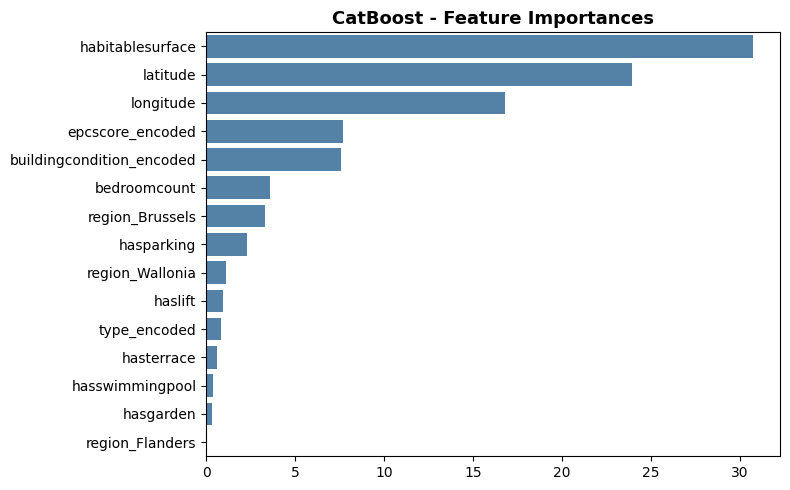

In [47]:
plotCatBoostImportance(catboost_importance)


In [48]:
# Top 3 features
selected_features = ['habitablesurface', 'latitude', 'longitude', 'price']
top3 = df_all[selected_features]

# Rerunning our best model with top 3 features
start = time.time()
results_df, catboost_importance = modelCAT(top3, target, "Rerun - Top 3 features", results_df)
end = time.time()

code_run = round((end - start) / 60, 3)
results_df.at[results_df.index[-1], "Runtime (min)"] = code_run

results_df = results_df.sort_values("RMSE (Test)", ascending=True)

print("\nSummary of Regression Results:")
print(results_df)




Summary of Regression Results:
      Model         Dataset                Features  Runtime (min)  R² Score (Train)  MAE (Train)  RMSE (Train)  R² Score (Test)  MAE (Test)  RMSE (Test)                  Model + Feat
0  CatBoost  All properties       All feat. + y log          2.210             0.813        0.161         0.212            0.782       0.173        0.229  CatBoost - All feat. + y log
1  CatBoost  All properties    Rerun - All features          2.171             0.813        0.161         0.212            0.782       0.173        0.229                           NaN
2  CatBoost  All properties                  Optuna          4.188             0.828        0.156         0.205            0.765       0.179        0.234             CatBoost - Optuna
3  CatBoost  All properties               RsearchCV         14.043             0.831        0.155         0.203            0.765       0.180        0.234          CatBoost - RsearchCV
4   XGBoost  All properties       All feat. + y 

C:\Users\bljor\AppData\Local\Temp\ipykernel_13980\1479442632.py:43: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([results_df, pd.DataFrame([combined_result])], ignore_index=True)


In [49]:
# Top 5 features
selected_features = ['habitablesurface', 'latitude', 'longitude','epcscore_encoded', 'buildingcondition_encoded', 'price']
top5 = df_all[selected_features]

# Rerunning our best model with top 5 features
start = time.time()
results_df, catboost_importance = modelCAT(top5, target, "Rerun - Top 5 features", results_df)
end = time.time()

code_run = round((end - start) / 60, 3)
results_df.at[results_df.index[-1], "Runtime (min)"] = code_run

results_df = results_df.sort_values("RMSE (Test)", ascending=True)

print("\nSummary of Regression Results:")
print(results_df)



Summary of Regression Results:
      Model         Dataset                Features  Runtime (min)  R² Score (Train)  MAE (Train)  RMSE (Train)  R² Score (Test)  MAE (Test)  RMSE (Test)                  Model + Feat
0  CatBoost  All properties       All feat. + y log          2.210             0.813        0.161         0.212            0.782       0.173        0.229  CatBoost - All feat. + y log
1  CatBoost  All properties    Rerun - All features          2.171             0.813        0.161         0.212            0.782       0.173        0.229                           NaN
2  CatBoost  All properties                  Optuna          4.188             0.828        0.156         0.205            0.765       0.179        0.234             CatBoost - Optuna
3  CatBoost  All properties               RsearchCV         14.043             0.831        0.155         0.203            0.765       0.180        0.234          CatBoost - RsearchCV
4   XGBoost  All properties       All feat. + y 

C:\Users\bljor\AppData\Local\Temp\ipykernel_13980\1479442632.py:43: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([results_df, pd.DataFrame([combined_result])], ignore_index=True)


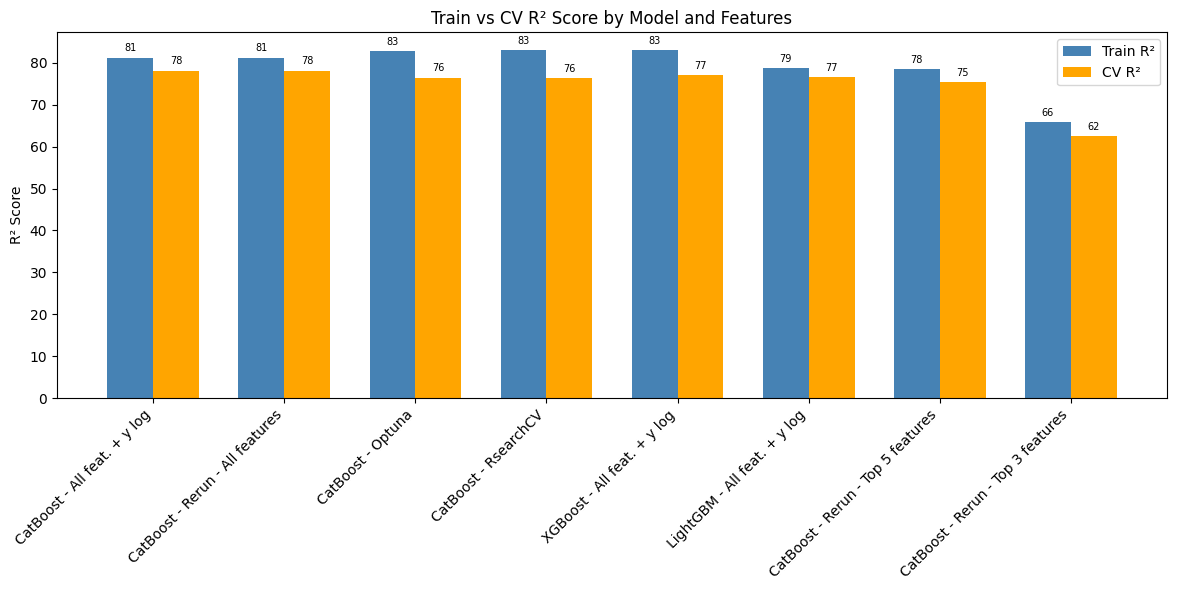

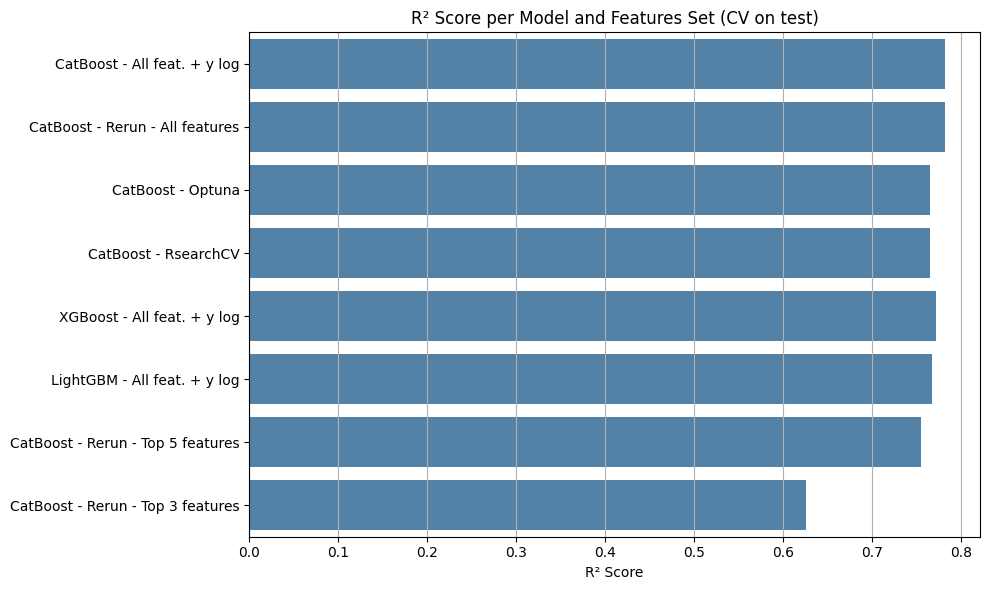

In [50]:
trainCVresult(results_df)
resultPlot(results_df)

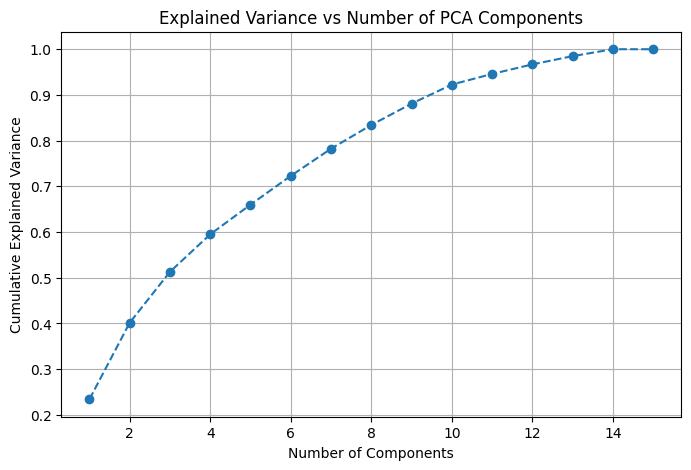

In [52]:
# Checking at PCA
# But result does not give a clear number of features (elbow): variance is spread out across many components.
# And we already tried with 3 and 5 features

X, y = splitDF(1, df_all, target)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Try PCA with all components (or max possible)
pca = PCA()
pca.fit(X_scaled)

# Calculate cumulative explained variance ratio
cumulative_variance = pca.explained_variance_ratio_.cumsum()

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs Number of PCA Components')
plt.grid(True)
plt.show()


# 

# RUN MODEL TO HOUSES AND APARTMENTS

In [61]:

datasets = {
    "Only Houses": df_hs,
    "Only Apartments": df_apt
}

for data, subset in datasets.items():
    start = time.time()
    results_df, catboost_importance = modelCAT(subset, target, f"{data} - All features", results_df)
    end = time.time()

    code_run = round((end - start) / 60, 3)
    results_df.at[results_df.index[-1], "Runtime (min)"] = code_run

    
results_df = results_df.sort_values(by=["Dataset", "RMSE (Test)"], ascending=True)
print("\nSummary of Regression Results:")
print(results_df)


C:\Users\bljor\AppData\Local\Temp\ipykernel_13980\1705443787.py:43: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([results_df, pd.DataFrame([combined_result])], ignore_index=True)
C:\Users\bljor\AppData\Local\Temp\ipykernel_13980\1705443787.py:43: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([results_df, pd.DataFrame([combined_result])], ignore_index=True)


TypeError: unhashable type: 'DataFrame'

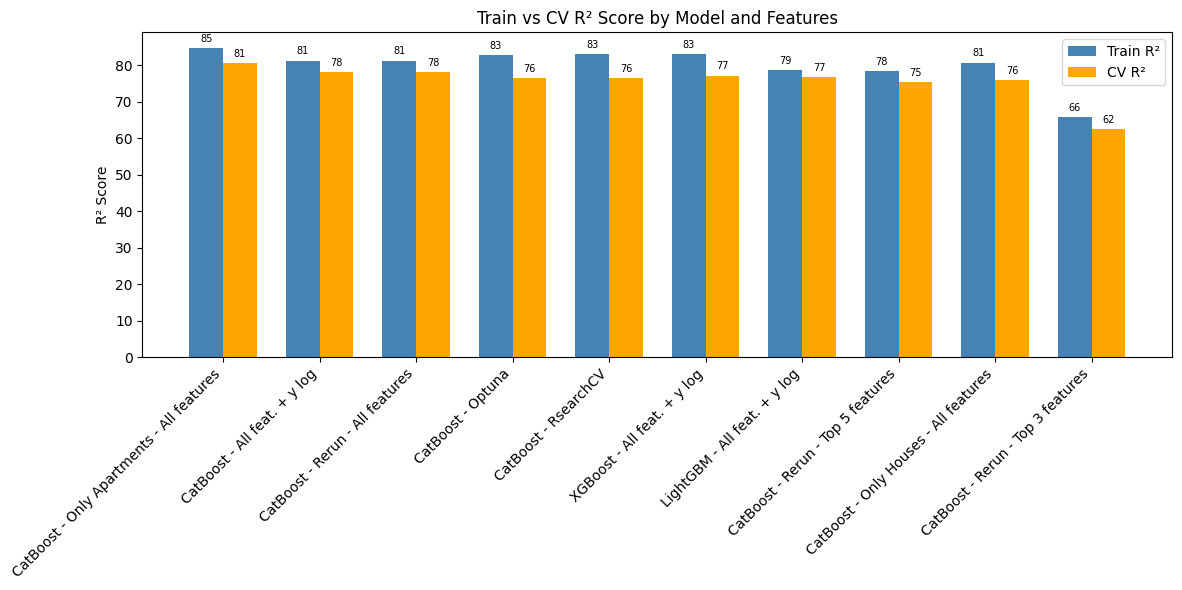

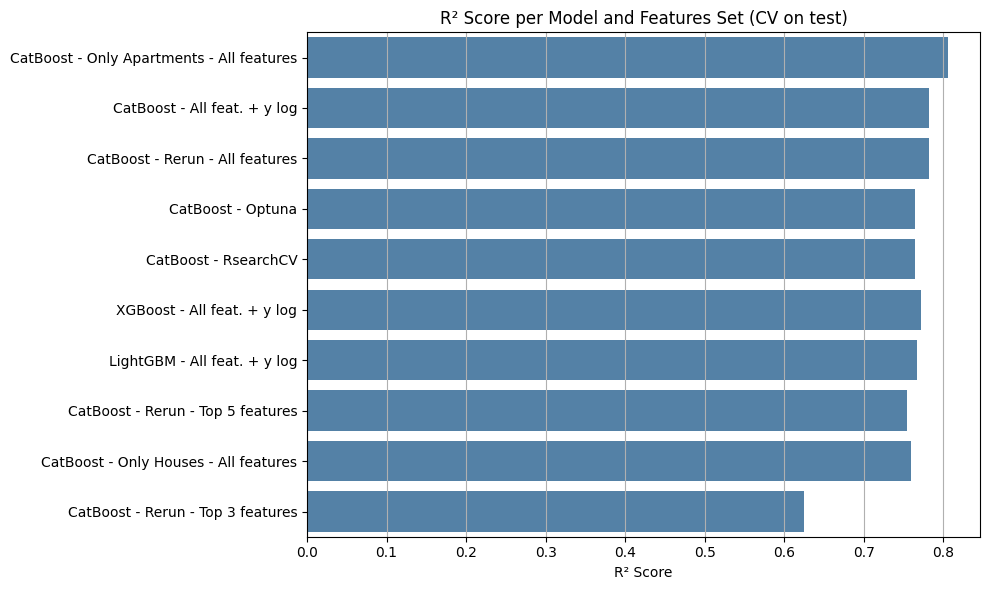

In [55]:
trainCVresult(results_df)
resultPlot(results_df)

Finally we see that our model fits better apartments than houses

In [58]:
results_df = results_df.sort_values(by=["Dataset", "RMSE (Test)"], ascending=True)
print("\nSummary of Regression Results:")
print(results_df)


Summary of Regression Results:
      Model         Dataset                        Features  Runtime (min)  R² Score (Train)  MAE (Train)  RMSE (Train)  R² Score (Test)  MAE (Test)  RMSE (Test)                               Model + Feat
9  CatBoost  All properties  Only Apartments - All features          1.705             0.848        0.134         0.176            0.806       0.151        0.199  CatBoost - Only Apartments - All features
0  CatBoost  All properties               All feat. + y log          2.210             0.813        0.161         0.212            0.782       0.173        0.229               CatBoost - All feat. + y log
1  CatBoost  All properties            Rerun - All features          2.171             0.813        0.161         0.212            0.782       0.173        0.229            CatBoost - Rerun - All features
2  CatBoost  All properties                          Optuna          4.188             0.828        0.156         0.205            0.765       0.179

In [56]:
r = results_df.sort_values(by=["Dataset", "RMSE"])
r
r.to_csv('Data/Regression_scores.csv', index=False)

KeyError: 'RMSE'